<a href="https://colab.research.google.com/github/PunyanuchChenya/AcademicoProject/blob/main/Project_code_Lapacian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Function

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
#sbert
from sentence_transformers import SentenceTransformer
#REDUSE
from sklearn.manifold import Isomap, LocallyLinearEmbedding, SpectralEmbedding
#CLASSIFICATION
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
#distortion
from scipy.spatial.distance import pdist
#CROSS VALIDATION
from sklearn.model_selection import StratifiedKFold , cross_validate

#find neighbors component
import time #  บอกเวลาว่าใช้ไปเท่าไหร่
import itertools # เรียกใช้เพื่อทำ Loop

Dataset

In [ ]:
# dataset
# Assuming the file is located in the root of your Google Drive
df = pd.read_csv("/content/drive/MyDrive/all_news.csv")
# print(df)

#กำหนดชื่อ columns
texts = df["statement"].astype(str).tolist()
labels = df["label"].tolist()

#นับจำนวนข่าว
print("ข่าวทั้งหมด:", len(texts),
      "Fake:", sum(df['label']==False),
      "Real:", sum(df['label']==True))

ข่าวทั้งหมด: 4142 Fake: 2248 Real: 1894


# แปลง label

In [ ]:
# ตรวจสอบค่าเดิมก่อน (อาจจะเป็น True/False หรือ real/fake)
print("Original labels:", df['label'].unique())

# แปลง label เป็น 0,1 เพื่อให้ง่ายต่อการจัดประเภท
mapping_rule = {True: 0, False: 1}

# ทำการแปลงและทับข้อมูลในคอลัมน์เดิม
df['label'] = df['label'].map(mapping_rule)
print("Mapped labels:", df['label'].unique())

# แล้วจึงดึงข้อมูลที่แปลงเป็น 0/1 แล้วออกมาเป็น List
labels = df["label"].tolist()

Original labels: [ True False]
Mapped labels: [0 1]


In [ ]:
print("ค่าที่มีอยู่ในคอลัมน์ 'label' และจำนวนของแต่ละค่า:")
print(df['label'].value_counts())

ค่าที่มีอยู่ในคอลัมน์ 'label' และจำนวนของแต่ละค่า:
label
1    2248
0    1894
Name: count, dtype: int64


# SBERT

In [ ]:
#แปลงข้อความเป็น vector
model = SentenceTransformer("all-MiniLM-L6-v2")
x = model.encode(texts) #vectorเชิงความหมาย
print("FINISH!!!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

FINISH!!!


In [ ]:
#สร้าง dataframe
df_x = pd.DataFrame(x)
y = np.array(labels) #label
df_x.shape

(4142, 384)

In [ ]:
# เช็ค label 5 ค่าแรก
print(y[:5])

[0 0 0 0 0]


#standarddize

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
means = np.mean(df_x, axis=0)
variances = np.var(df_x, axis=0)
dimensions = np.arange(1,len(means)+1)

result_df = pd.DataFrame({
    'มิติที่': dimensions,
    'ค่าเฉลี่ย': means,
    'ความแปรปรวน': variances
})

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print(result_df)

print(f"\n\nค่าเฉลี่ยสูงสุด : {np.max(means):.6f}")
print(f"ค่าเฉลี่ยต่ำสุด : {np.min(means):.6f}")
print(f"ค่าเฉลี่ยรวม : :{np.mean(means):.6f}")

print(f"ความแปรปรวนสูงสุด : {np.max(variances):.6f}")
print(f"ความแปรปรวนต่ำสุด : {np.min(variances):.6f}")
print(f"ความแปรปรวนเฉลี่ย : {np.mean(variances):.6f}")

     มิติที่     ค่าเฉลี่ย   ความแปรปรวน
0          1  1.649827e-02  2.750656e-03
1          2  6.354412e-03  2.748838e-03
2          3  1.141568e-02  2.127985e-03
3          4  1.268768e-02  1.795725e-03
4          5  1.575310e-03  2.252149e-03
5          6  1.043029e-02  1.946362e-03
6          7 -5.095637e-03  3.007407e-03
7          8 -1.755122e-02  2.291837e-03
8          9 -2.613895e-02  1.921879e-03
9         10  1.199922e-02  1.831683e-03
10        11  1.362235e-02  2.208479e-03
11        12  4.604961e-02  2.804464e-03
12        13  9.123784e-03  2.256036e-03
13        14 -1.717272e-02  1.964042e-03
14        15 -1.426047e-02  2.092231e-03
15        16  1.868848e-02  2.152673e-03
16        17  2.892287e-03  2.187950e-03
17        18 -1.515119e-02  2.476426e-03
18        19 -6.135425e-03  2.069787e-03
19        20  1.737299e-02  2.882108e-03
20        21  8.046625e-03  3.241579e-03
21        22  1.124575e-02  2.158617e-03
22        23  1.788184e-02  2.604170e-03
23        24  1.

In [ ]:
scaler = StandardScaler()
df_x_sc = scaler.fit_transform(df_x)

In [ ]:
means = np.mean(df_x_sc, axis=0)
variances = np.var(df_x_sc, axis=0)
dimensions = np.arange(1,len(means)+1)

result_df = pd.DataFrame({
    'มิติที่': dimensions,
    'ค่าเฉลี่ย': means,
    'ความแปรปรวน': variances
})

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print(result_df)

print(f"\n\nค่าเฉลี่ยสูงสุด : {np.max(means):.6f}")
print(f"ค่าเฉลี่ยต่ำสุด : {np.min(means):.6f}")
print(f"ค่าเฉลี่ยรวม : :{np.mean(means):.6f}")

print(f"ความแปรปรวนสูงสุด : {np.max(variances):.6f}")
print(f"ความแปรปรวนต่ำสุด : {np.min(variances):.6f}")
print(f"ความแปรปรวนเฉลี่ย : {np.mean(variances):.6f}")

     มิติที่     ค่าเฉลี่ย  ความแปรปรวน
0          1 -1.721081e-08     1.000000
1          2  9.848725e-08     1.000001
2          3 -1.093663e-08     1.000001
3          4  7.554911e-10     1.000000
4          5 -3.879986e-09     0.999997
5          6 -2.614718e-08     0.999999
6          7  9.065892e-09     1.000000
7          8 -5.745330e-09     1.000000
8          9  7.655642e-09     1.000001
9         10  1.102297e-08     1.000000
10        11  3.337831e-08     1.000000
11        12 -2.499776e-08     0.999999
12        13 -4.722898e-08     1.000000
13        14 -4.907094e-09     0.999999
14        15 -9.986872e-09     1.000001
15        16 -2.489523e-09     0.999998
16        17  4.669654e-09     0.999999
17        18 -2.132643e-08     1.000001
18        19  5.561853e-09     1.000000
19        20 -3.486771e-08     1.000000
20        21  1.151224e-10     1.000000
21        22  3.352941e-09     0.999998
22        23 -3.257965e-08     1.000000
23        24 -4.662459e-09     1.000000




---



# correlation

In [ ]:
# @title
cor_x = np.corrcoef(df_x,rowvar = False ) # หา corr matrix
print(f'Correlation matrix {cor_x}')
cor_x.shape

Correlation matrix [[ 1.         -0.18577736  0.03341927 ...  0.03805516  0.03232404
   0.07124142]
 [-0.18577736  1.         -0.05023263 ...  0.03371192 -0.07041911
  -0.08634386]
 [ 0.03341927 -0.05023263  1.         ... -0.03929206 -0.10288287
   0.1654066 ]
 ...
 [ 0.03805516  0.03371192 -0.03929206 ...  1.          0.04866204
  -0.10253805]
 [ 0.03232404 -0.07041911 -0.10288287 ...  0.04866204  1.
   0.06200885]
 [ 0.07124142 -0.08634386  0.1654066  ... -0.10253805  0.06200885
   1.        ]]


(384, 384)

Axes(0.125,0.11;0.62x0.77)


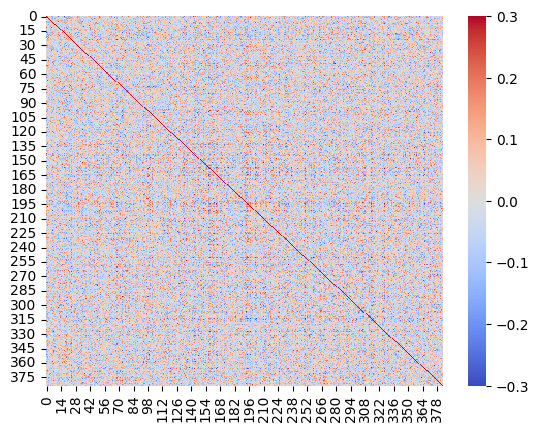

In [ ]:
# @title
# heatmap cor
heatmap = sns.heatmap(cor_x, cmap='coolwarm', vmin=-0.3, vmax=0.3)
print(heatmap)



---



NOTE เพื่อทำความเข้าใจ

n_jobs ทำงานอย่างไร
ลองนึกภาพว่าการสร้าง Random Forest (n_estimators=100) ต้นไม้ 100 ต้น

n_jobs=1 (ค่าเริ่มต้น): ใช้คน 1 คน สร้างต้นไม้ 100 ต้น

n_jobs=2: ใช้ 2 คน สร้างต้นไม้ 100 ต้น เสร็จเร็วขึ้น

n_jobs=-1: ใช้ทุกคนที่มี สร้างต้นไม้ 100 ต้น อันนี้เสร็จไวสุด

####NOTE



ถ้าเป้าหมายหลักคือ...	     // ความผิดพลาดที่รับไม่ได้คือ...	  //   Metric ที่ควรดูเป็นหลัก


ความแม่นยำในการชี้เป้า	    // กล่าวหาข่าวจริงว่าเป็นข่าวปลอม (False Positive)	// Precision, F0.5-Score


ความครอบคลุมในการตรวจจับ //	ปล่อยข่าวปลอมให้หลุดรอดไป (False Negative)	// Recall, F2-Score



ความสมดุล	// ทั้งสองอย่างสำคัญเท่ากัน	// F1-Score (มาตรฐาน)

#### F1 Macro: หนึ่งในวิธีแก้ปัญหา
F1 Macro คือวิธีการเฉลี่ยคะแนน F1 ของทุกคลาส แบบเท่าเทียมกัน โดยไม่สนใจว่าคลาสไหนมีข้อมูลเยอะหรือน้อย

วิธีการคือ:

หา F1 Score ของคลาส "การเมือง" (สมมติได้ 0.9)

หา F1 Score ของคลาส "กีฬา" (สมมติได้ 0.8)

หา F1 Score ของคลาส "บันเทิง" (สมมติได้ 0.7)

นำคะแนนทั้งหมดมาบวกกันแล้วหารด้วยจำนวนคลาส: (0.9 + 0.8 + 0.7) / 3 = 0.8

ดังนั้น F1 Macro Score ของโมเดลนี้คือ 0.8

สรุป: F1 Score คือตัวชี้วัด ส่วน F1 Macro คือวิธีการหาค่าเฉลี่ยของตัวชี้วัดนั้นในกรณีที่มีหลายคลาสนั่นเองครับ

#LOOP ใช้

In [ ]:
# @title
import pandas as pd
import numpy as np
from sklearn.manifold import SpectralEmbedding
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.datasets import make_classification
from scipy.spatial.distance import pdist

# เมตริกที่ต้องการวัดผล
scoring_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

print(f"ขนาดข้อมูลเริ่มต้น: {x.shape}")
print("-" * 40)


# --- กำหนดค่าพารามิเตอร์ที่ต้องการทดลอง ---
n_neighbors_list = [5,45,85,125,165]
n_components_list = [50, 100, 150, 200,227]

# สร้าง list ว่างสำหรับเก็บผลลัพธ์ของแต่ละรอบ
results_list = []


# --- เริ่มการวนลูปเพื่อทดลองพารามิเตอร์ ---
for n_neighbors in n_neighbors_list:
    for n_components in n_components_list:
        print(f"\n===== กำลังทดลอง: Neighbors = {n_neighbors}, Components = {n_components} =====")

        # --- สร้างโมเดล SpectralEmbedding ---
        laplacian_model = SpectralEmbedding(
            n_components=n_components,
            n_neighbors=n_neighbors,
            random_state=42,
            n_jobs=1 # ใช้ CPU ทั้งหมดเพื่อความเร็ว
        )

        # ทำการลดมิติข้อมูล
        X_Laplacian = laplacian_model.fit_transform(df_x_sc)
        print(f"ขนาดข้อมูลหลังลดมิติ: {X_Laplacian.shape}")

        # --- วัดค่า Distortion ---
        dist_original = pdist(x)
        dist_reduced = pdist(X_Laplacian)
        numerator = np.sum((dist_original - dist_reduced)**2)
        denominator = np.sum(dist_original**2)
        stress_value = np.sqrt(numerator / denominator)
        print(f"Normalized Stress: {stress_value:.4f}")

        # --- สร้างโมเดล Random Forest และประเมินผล ---
        model_RANDOM = RandomForestClassifier(n_estimators=200,
                        max_depth=10,
                        min_samples_split=2, random_state=42, n_jobs=1)

        cv_results_Laplacian = cross_validate(
            estimator=model_RANDOM,
            X=X_Laplacian,
            y=y,
            cv=5,
            scoring=scoring_metrics
        )

        # --- เก็บผลลัพธ์ลงใน Dictionary ---
        current_result = {
            'n_neighbors': n_neighbors,
            'n_components': n_components,
            'stress': stress_value,
            'fit_time': cv_results_Laplacian['fit_time'].mean(),
            'score_time': cv_results_Laplacian['score_time'].mean(),
            'accuracy': cv_results_Laplacian['test_accuracy'].mean(),
            'precision': cv_results_Laplacian['test_precision_macro'].mean(),
            'recall': cv_results_Laplacian['test_recall_macro'].mean(),
            'f1_score': cv_results_Laplacian['test_f1_macro'].mean()
        }

        # เพิ่ม dictionary ของรอบนี้เข้าไปใน list กลาง
        results_list.append(current_result)
        print("-" * 40)

ขนาดข้อมูลเริ่มต้น: (4142, 384)
----------------------------------------

===== กำลังทดลอง: Neighbors = 5, Components = 50 =====
ขนาดข้อมูลหลังลดมิติ: (4142, 50)
Normalized Stress: 0.9487
----------------------------------------

===== กำลังทดลอง: Neighbors = 5, Components = 100 =====
ขนาดข้อมูลหลังลดมิติ: (4142, 100)
Normalized Stress: 0.9239
----------------------------------------

===== กำลังทดลอง: Neighbors = 5, Components = 150 =====
ขนาดข้อมูลหลังลดมิติ: (4142, 150)
Normalized Stress: 0.9039
----------------------------------------

===== กำลังทดลอง: Neighbors = 5, Components = 200 =====
ขนาดข้อมูลหลังลดมิติ: (4142, 200)
Normalized Stress: 0.8866
----------------------------------------

===== กำลังทดลอง: Neighbors = 5, Components = 227 =====
ขนาดข้อมูลหลังลดมิติ: (4142, 227)
Normalized Stress: 0.8783
----------------------------------------

===== กำลังทดลอง: Neighbors = 45, Components = 50 =====
ขนาดข้อมูลหลังลดมิติ: (4142, 50)
Normalized Stress: 0.9826
-----------------------

In [ ]:
# @title

# --- สรุปผลลัพธ์ทั้งหมด ---
print("\n\n--- สรุปผลการทดลองทั้งหมด ---")

# แปลง list ของผลลัพธ์เป็น Pandas DataFrame เพื่อให้ดูสวยงาม
results_df = pd.DataFrame(results_list)

# จัดเรียงตารางตาม f1-score จากมากไปน้อย
kresults_df = results_df.sort_values(by='f1_score', ascending=False).reset_index(drop=True)

print(results_df)
print(kresults_df)



--- สรุปผลการทดลองทั้งหมด ---
    n_neighbors  n_components    stress   fit_time  score_time  accuracy  \
0             5            50  0.948740   9.729605    0.139512  0.600914   
1             5           100  0.923915  10.462367    0.045862  0.605502   
2             5           150  0.903870  12.258951    0.100851  0.608881   
3             5           200  0.886635  14.067209    0.047305  0.608643   
4             5           227  0.878285  15.087476    0.059187  0.602851   
5            45            50  0.982597   7.269167    0.050819  0.607439   
6            45           100  0.974549  10.266030    0.047688  0.606954   
7            45           150  0.968412  11.991265    0.046804  0.604301   
8            45           200  0.963203  14.163704    0.047343  0.605028   
9            45           227  0.960668  15.020858    0.043594  0.610096   
10           85            50  0.987104   7.190892    0.052885  0.612264   
11           85           100  0.981313  10.305306    0.

In [ ]:
# @title
# --- แสดงผลลัพธ์ที่ดีที่สุด ---
best_result = results_df.iloc[0] # แถวแรกคือผลที่ดีที่สุด
print("\n--- ผลลัพธ์ที่ดีที่สุด (วัดจาก F1-Score) ---")
print(f"จำนวน Neighbors (n_neighbors): {best_result['n_neighbors']}")
print(f"จำนวน Components (n_components): {best_result['n_components']}")
print(f"F1-Score: {best_result['f1_score']:.4f}")
print(f"Accuracy: {best_result['accuracy']:.4f}")
print(f"Normalized Stress: {best_result['stress']:.4f}")


--- ผลลัพธ์ที่ดีที่สุด (วัดจาก F1-Score) ---
จำนวน Neighbors (n_neighbors): 40.0
จำนวน Components (n_components): 50.0
F1-Score: 0.5894
Accuracy: 0.6057
Normalized Stress: 0.9816


In [ ]:
# @title
# สมมติว่า results_df คือ DataFrame ที่มีผลลัพธ์ทั้งหมดของคุณ


excel_file_name = 'laplacian_tuning_results11.xlsx'

# ใช้คำสั่ง .to_excel() เพื่อบันทึก
results_df.to_excel(
    excel_file_name,
    sheet_name='Tuning_Results',  # (Optional) สามารถตั้งชื่อชีตใน Excel ได้
    index=False                 # (สำคัญ!) ไม่ต้องเอาคอลัมน์ index (0, 1, 2...) ไปใส่ในไฟล์ Excel
)

print(f"\n บันทึกข้อมูลลงในไฟล์ '{excel_file_name}' เรียบร้อยแล้วครับ")


 บันทึกข้อมูลลงในไฟล์ 'laplacian_tuning_results11.xlsx' เรียบร้อยแล้วครับ


In [ ]:
# @title

# 1. กำหนดตำแหน่งและชื่อไฟล์ในโฟลเดอร์ 'PROJECT FILE'
drive_file_path = '/content/drive/MyDrive/PROJECTFILE/laplacian_tuning_results12.xlsx'

# 2. ใช้คำสั่ง .to_excel() เพื่อบันทึกไปยังตำแหน่งที่กำหนดไว้
results_df.to_excel(
    drive_file_path,
    sheet_name='Tuning_Results',
    index=False
)

print(f"\n✅ บันทึกข้อมูลลงใน Google Drive ที่ '{drive_file_path}' เรียบร้อยแล้วครับ")


✅ บันทึกข้อมูลลงใน Google Drive ที่ '/content/drive/MyDrive/PROJECTFILE/laplacian_tuning_results12.xlsx' เรียบร้อยแล้วครับ


#LOOP REDECE&RF

In [ ]:
scoring_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

print(f"ขนาดข้อมูลเริ่มต้น: {df_x_sc.shape}")
print("-" * 50)


# --- กำหนดค่าพารามิเตอร์ที่ต้องการทดลอง ---
# Spectral Embedding params
n_neighbors_list = [5,45,85,125,165]
n_components_list = [50, 100, 150,200,227]
# RandomForest params
max_depth_list = [2,5,10]
n_estimators_list = [100,200,300]
min_samples_split_list = [2, 5,10]

# สร้าง list ว่างสำหรับเก็บผลลัพธ์
results_list = []
start_time = time.time()

# --- เริ่มการวนลูปเพื่อทดลองพารามิเตอร์ ---
for n_neighbors in n_neighbors_list:
    for n_components in n_components_list:
        print(f"\n===== LE: Neighbors={n_neighbors}, Components={n_components} =====")

        # ลดมิติข้อมูล (ทำครั้งเดียวก่อน Loop ของ RF)
        laplacian_model = SpectralEmbedding(
            n_components=n_components, n_neighbors=n_neighbors,
            random_state=42, n_jobs=1)

        X_Laplacian = laplacian_model.fit_transform(df_x_sc)

        dist_original = pdist(df_x_sc)
        dist_reduced = pdist(X_Laplacian)
        stress_value = np.sqrt(np.sum((dist_original - dist_reduced)**2) / np.sum(dist_original**2))

        # *** เริ่ม Loop สำหรับพารามิเตอร์ของ RandomForest ***
        for max_depth in max_depth_list:
            for n_estimators in n_estimators_list:
                for min_samples_split in min_samples_split_list:
                    print(f"--- Testing RF: max_depth={max_depth}, n_estimators={n_estimators}, min_samples_split={min_samples_split} ---")

                    model_RANDOM = RandomForestClassifier(
                        n_estimators=n_estimators,
                        max_depth=max_depth,
                        min_samples_split=min_samples_split,
                        random_state=42,
                        n_jobs=1)

                    cv_results_Laplacian = cross_validate(
                        estimator=model_RANDOM, X=X_Laplacian, y=y,
                        cv=5, scoring=scoring_metrics)

                    current_result = {
                        'n_neighbors': n_neighbors,
                        'n_components': n_components,
                        'max_depth': max_depth,
                        'n_estimators': n_estimators,
                        'min_samples_split': min_samples_split,
                        'stress': stress_value,
                        'fit_time': cv_results_Laplacian['fit_time'].mean(),
                        'score_time': cv_results_Laplacian['score_time'].mean(),
                        'accuracy': cv_results_Laplacian['test_accuracy'].mean(),
                        'precision': cv_results_Laplacian['test_precision_macro'].mean(),
                        'recall': cv_results_Laplacian['test_recall_macro'].mean(),
                        'f1_score': cv_results_Laplacian['test_f1_macro'].mean()
                    }
                    results_list.append(current_result)
        print("-" * 50)

end_time = time.time()
print(f"\n\nใช้เวลาประมวลผลทั้งหมด: {end_time - start_time:.2f} วินาที")
results_df_rf = pd.DataFrame(results_list)


ขนาดข้อมูลเริ่มต้น: (4142, 384)
--------------------------------------------------

===== LE: Neighbors=5, Components=50 =====
--- Testing RF: max_depth=2, n_estimators=100, min_samples_split=2 ---
--- Testing RF: max_depth=2, n_estimators=100, min_samples_split=5 ---
--- Testing RF: max_depth=2, n_estimators=100, min_samples_split=10 ---
--- Testing RF: max_depth=2, n_estimators=200, min_samples_split=2 ---
--- Testing RF: max_depth=2, n_estimators=200, min_samples_split=5 ---
--- Testing RF: max_depth=2, n_estimators=200, min_samples_split=10 ---
--- Testing RF: max_depth=2, n_estimators=300, min_samples_split=2 ---
--- Testing RF: max_depth=2, n_estimators=300, min_samples_split=5 ---
--- Testing RF: max_depth=2, n_estimators=300, min_samples_split=10 ---
--- Testing RF: max_depth=5, n_estimators=100, min_samples_split=2 ---
--- Testing RF: max_depth=5, n_estimators=100, min_samples_split=5 ---
--- Testing RF: max_depth=5, n_estimators=100, min_samples_split=10 ---
--- Testing RF: m

In [ ]:
# @title
best_results = results_df.sort_values(by='f1_score', ascending=False)

print("\n\n===== สรุปผลการทดลองทั้งหมด (เรียงตาม F1-Score) =====")
print(best_results.to_string())

print("\n\n===== ✨ การตั้งค่าที่ดีที่สุด (ตาม F1-Score) ✨ =====")
print(best_results.iloc[0])



===== สรุปผลการทดลองทั้งหมด (เรียงตาม F1-Score) =====
     n_neighbors  n_components  max_depth  n_estimators  min_samples_split    stress   fit_time  accuracy  precision    recall  f1_score
561          150            50         10           200                  2  0.990172   6.189263  0.620963   0.621207  0.606488  0.601389
564          150            50         10           300                  2  0.990172   9.251976  0.620480   0.620633  0.605961  0.600803
454          120            50         10           200                  5  0.989063   6.255309  0.617823   0.616684  0.604298  0.600125
452          120            50         10           100                 10  0.989063   3.088303  0.616376   0.614919  0.603181  0.599163
457          120            50         10           300                  5  0.989063   9.149799  0.616617   0.615339  0.602938  0.598589
239           90            50         10           200                 10  0.987455   6.005036  0.617581   0.617072  0.60

In [ ]:
# @title
# สมมติว่า results_df คือ DataFrame ที่มีผลลัพธ์ทั้งหมดของคุณ


excel_file_name = 'laplacian_tuning_results_rf11.xlsx'

# ใช้คำสั่ง .to_excel() เพื่อบันทึก
results_df_rf.to_excel(
    excel_file_name,
    sheet_name='Tuning_Results',  # (Optional) สามารถตั้งชื่อชีตใน Excel ได้
    index=False                 # (สำคัญ!) ไม่ต้องเอาคอลัมน์ index (0, 1, 2...) ไปใส่ในไฟล์ Excel
)

print(f"\n บันทึกข้อมูลลงในไฟล์ '{excel_file_name}' เรียบร้อยแล้วครับ")


 บันทึกข้อมูลลงในไฟล์ 'laplacian_tuning_results_rf11.xlsx' เรียบร้อยแล้วครับ


In [ ]:
# @title

# 1. กำหนดตำแหน่งและชื่อไฟล์ในโฟลเดอร์ 'PROJECT FILE'
drive_file_path = '/content/drive/MyDrive/PROJECTFILE/laplacian_tuning_results_rf13.xlsx'

# 2. ใช้คำสั่ง .to_excel() เพื่อบันทึกไปยังตำแหน่งที่กำหนดไว้
results_df_rf.to_excel(
    drive_file_path,
    sheet_name='Tuning_Results',
    index=False
)

print(f"\n✅ บันทึกข้อมูลลงใน Google Drive ที่ '{drive_file_path}' เรียบร้อยแล้วครับ")


✅ บันทึกข้อมูลลงใน Google Drive ที่ '/content/drive/MyDrive/PROJECTFILE/laplacian_tuning_results_rf13.xlsx' เรียบร้อยแล้วครับ


#เปรียบเทียบ

##ก่อนลด

In [ ]:
# @title
#สร้าง model ให้เดียวกับ rf ที่ดีที่สุดใน laplacian
model_baseline = RandomForestClassifier(n_estimators=200,max_depth=10,min_samples_split=2, random_state=42,n_jobs=1)

In [ ]:
# @title
# --- กำหนดเมตริกที่ต้องการวัดผล ---
scoring_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

# --- เรียกใช้ cross_validate ---
# เพื่อให้ข้อมูลถูกแบ่งแบบเดิมเป๊ะๆ ทุกครั้ง ใช้ StratifiedKFold
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
# @title
# cross_validate จะคืนค่าเป็น dictionary ที่มีข้อมูลการทำงานและคะแนนทั้งหมด
cv_results = cross_validate(
    estimator=model_baseline,
    X=x,
    y=y,
    cv=cv_strategy,
    scoring=scoring_metrics
)

In [ ]:
# @title
# --- แสดงผลลัพธ์ ---
print("\n--- ผลลัพธ์การประเมินผล ก่อนลดมิติ ---")
print(f"ระยะเวลาในการฝึก (Fit Time): {cv_results['fit_time'].mean():.2f} วินาที")
print(f"ระยะเวลาในการทดสอบ (Score Time): {cv_results['score_time'].mean():.2f} วินาที")
print("-" * 30)

# แสดงค่าเฉลี่ยและค่าเบี่ยงเบนมาตรฐานของแต่ละเมตริก
mean_accuracy = cv_results['test_accuracy'].mean()
std_accuracy = cv_results['test_accuracy'].std()
print(f"Accuracy: {mean_accuracy:.4f} (+/- {std_accuracy:.4f})")

mean_precision = cv_results['test_precision_macro'].mean()
std_precision = cv_results['test_precision_macro'].std()
print(f"Precision: {mean_precision:.4f} (+/- {std_precision:.4f})")

mean_recall = cv_results['test_recall_macro'].mean()
std_recall = cv_results['test_recall_macro'].std()
print(f"Recall: {mean_recall:.4f} (+/- {std_recall:.4f})")

mean_f1 = cv_results['test_f1_macro'].mean()
std_f1 = cv_results['test_f1_macro'].std()
print(f"F1-Score: {mean_f1:.4f} (+/- {std_f1:.4f})")


--- ผลลัพธ์การประเมินผล ก่อนลดมิติ ---
ระยะเวลาในการฝึก (Fit Time): 15.50 วินาที
ระยะเวลาในการทดสอบ (Score Time): 0.06 วินาที
------------------------------
Accuracy: 0.6154 (+/- 0.0109)
Precision: 0.6196 (+/- 0.0135)
Recall: 0.5975 (+/- 0.0113)
F1-Score: 0.5873 (+/- 0.0128)


##หลังลด

In [ ]:
# @title
best_n_components = 50
best_n_neighbors = 150

In [ ]:
# @title
# --- สร้างโมเดล ---
print(f"ขนาดข้อมูลเริ่มต้น: {x.shape}")

# สร้างโมเดล SpectralEmbedding
laplacian_model = SpectralEmbedding(
    n_components=best_n_components,
    n_neighbors=best_n_neighbors,
    random_state=42 # เพื่อให้ผลลัพธ์เหมือนเดิมทุกครั้ง
)

# ทำการลดมิติข้อมูล
X_Laplacian = laplacian_model.fit_transform(x)

print(f"ขนาดข้อมูลหลังลดมิติ: {X_Laplacian.shape}")

# ตอนนี้ 'X_Laplacian' คือข้อมูลใหม่ที่พร้อมนำไปใช้กับ Random Forest

ขนาดข้อมูลเริ่มต้น: (4142, 384)
ขนาดข้อมูลหลังลดมิติ: (4142, 50)


In [ ]:
# @title
# --- สร้างโมเดล ---
model_RANDOM = RandomForestClassifier(n_estimators=200,max_depth=10,min_samples_split=2, random_state=42,n_jobs=1)

In [ ]:
# @title
# cv_strategy อยู่ตรงยังไม่ลด
# cross_validate จะคืนค่าเป็น dictionary ที่มีข้อมูลการทำงานและคะแนนทั้งหมด
cv_results_Laplacian = cross_validate(
    estimator=model_RANDOM,
    X=X_Laplacian,
    y=y,
    cv=cv_strategy,
    scoring=scoring_metrics
)

In [ ]:
# @title
# --- แสดงผลลัพธ์ ---
print("\n--- ผลลัพธ์การประเมินผล หลังลดมิติ ---")
print(f"ระยะเวลาในการฝึก (Fit Time): {cv_results_Laplacian['fit_time'].mean():.2f} วินาที")
print(f"ระยะเวลาในการทดสอบ (Score Time): {cv_results_Laplacian['score_time'].mean():.2f} วินาที")
print("-" * 30)

# แสดงค่าเฉลี่ยและค่าเบี่ยงเบนมาตรฐานของแต่ละเมตริก
mean_accuracy_Laplacian = cv_results_Laplacian['test_accuracy'].mean()
std_accuracy_Laplacian = cv_results_Laplacian['test_accuracy'].std()
print(f"Accuracy (Laplacian): {mean_accuracy_Laplacian:.4f} (+/- {std_accuracy_Laplacian:.4f})")

mean_precision_Laplacian = cv_results_Laplacian['test_precision_macro'].mean()
std_precision_Laplacian = cv_results_Laplacian['test_precision_macro'].std()
print(f"Precision (Laplacian): {mean_precision_Laplacian:.4f} (+/- {std_precision_Laplacian:.4f})")

mean_recall_Laplacian = cv_results_Laplacian['test_recall_macro'].mean()
std_recall_Laplacian = cv_results_Laplacian['test_recall_macro'].std()
print(f"Recall (Laplacian): {mean_recall_Laplacian:.4f} (+/- {std_recall_Laplacian:.4f})")

mean_f1_Laplacian = cv_results_Laplacian['test_f1_macro'].mean()
std_f1_Laplacian = cv_results_Laplacian['test_f1_macro'].std()
print(f"F1-Score (Laplacian): {mean_f1_Laplacian:.4f} (+/- {std_f1_Laplacian:.4f})")


--- ผลลัพธ์การประเมินผล หลังลดมิติ ---
ระยะเวลาในการฝึก (Fit Time): 6.85 วินาที
ระยะเวลาในการทดสอบ (Score Time): 0.05 วินาที
------------------------------
Accuracy (Laplacian): 0.6210 (+/- 0.0127)
Precision (Laplacian): 0.6212 (+/- 0.0144)
Recall (Laplacian): 0.6065 (+/- 0.0130)
F1-Score (Laplacian): 0.6014 (+/- 0.0137)


In [ ]:
# @title
comparison_data_Laplacian = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Fit Time (s)', 'Score Time (s)'],
    'Before Laplacian (Mean)': [mean_accuracy, mean_precision, mean_recall, mean_f1, cv_results['fit_time'].mean(), cv_results['score_time'].mean()],
    'Before Laplacian (Std)': [std_accuracy, std_precision, std_recall, std_f1, cv_results['fit_time'].std(), cv_results['score_time'].std()],
    'After Laplacian (Mean)': [mean_accuracy_Laplacian, mean_precision_Laplacian, mean_recall_Laplacian, mean_f1_Laplacian, cv_results_Laplacian['fit_time'].mean(), cv_results_Laplacian['score_time'].mean()],
    'After Laplacian (Std)': [std_accuracy_Laplacian, std_precision_Laplacian, std_recall_Laplacian, std_f1_Laplacian, cv_results_Laplacian['fit_time'].std(), cv_results_Laplacian['score_time'].std()]
}

comparison_df_Laplacian = pd.DataFrame(comparison_data_Laplacian)

# แสดงตารางเปรียบเทียบ
print("--- ตารางเปรียบเทียบผลลัพธ์การจัดประเภท ก่อนและหลังลดมิติด้วย Laplacian ---")
display(comparison_df_Laplacian)

if mean_accuracy_Laplacian > mean_accuracy:
    print("Accuracy หลังลดมิติด้วย Laplacian สูงกว่าก่อนลดมิติ")
elif mean_accuracy_Laplacian < mean_accuracy:
    print("Accuracy หลังลดมิติด้วย Laplacian ต่ำกว่าก่อนลดมิติ")
else:
    print("Accuracy หลังและก่อนลดมิติด้วย Laplacian เท่ากัน")

if cv_results_Laplacian['fit_time'].mean() < cv_results['fit_time'].mean():
    print(f"ใช้เวลาในการฝึก (Fit Time) หลังลดมิติด้วย Laplacian น้อยกว่า ({cv_results_Laplacian['fit_time'].mean():.2f}s < {cv_results['fit_time'].mean():.2f}s)")
elif cv_results_Laplacian['fit_time'].mean() > cv_results['fit_time'].mean():
     print(f"ใช้เวลาในการฝึก (Fit Time) หลังลดมิติด้วย Laplacian มากกว่า ({cv_results_Laplacian['fit_time'].mean():.2f}s > {cv_results['fit_time'].mean():.2f}s)")
else:
    print("ใช้เวลาในการฝึก (Fit Time) หลังและก่อนลดมิติด้วย Laplacian เท่ากัน")

--- ตารางเปรียบเทียบผลลัพธ์การจัดประเภท ก่อนและหลังลดมิติด้วย Laplacian ---


,Metric,Before Laplacian (Mean),Before Laplacian (Std),After Laplacian (Mean),After Laplacian (Std)
0,Accuracy,0.615409,0.010932,0.620963,0.012680
1,Precision,0.619552,0.013536,0.621207,0.014384
2,Recall,0.597544,0.011296,0.606488,0.012971
3,F1-Score,0.587348,0.012848,0.601389,0.013723
4,Fit Time (s),15.497578,0.619732,6.846285,1.377627
5,Score Time (s),0.058286,0.007594,0.048634,0.008067


Accuracy หลังลดมิติด้วย Laplacian สูงกว่าก่อนลดมิติ
ใช้เวลาในการฝึก (Fit Time) หลังลดมิติด้วย Laplacian น้อยกว่า (6.85s < 15.50s)


# LOOP no STANSARDIZE

## LOOP

In [ ]:
# @title
import pandas as pd
import numpy as np
from sklearn.manifold import SpectralEmbedding
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.datasets import make_classification
from scipy.spatial.distance import pdist

# เมตริกที่ต้องการวัดผล
scoring_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

print(f"ขนาดข้อมูลเริ่มต้น: {x.shape}")
print("-" * 40)


# --- กำหนดค่าพารามิเตอร์ที่ต้องการทดลอง ---
n_neighbors_list = [5,45,85,125,165]
n_components_list = [50, 100, 150, 200,227]

# สร้าง list ว่างสำหรับเก็บผลลัพธ์ของแต่ละรอบ
results_list = []


# --- เริ่มการวนลูปเพื่อทดลองพารามิเตอร์ ---
for n_neighbors in n_neighbors_list:
    for n_components in n_components_list:
        print(f"\n===== กำลังทดลอง: Neighbors = {n_neighbors}, Components = {n_components} =====")

        # --- สร้างโมเดล SpectralEmbedding ---
        laplacian_model = SpectralEmbedding(
            n_components=n_components,
            n_neighbors=n_neighbors,
            random_state=42,
            n_jobs=1 # ใช้ CPU ทั้งหมดเพื่อความเร็ว
        )

        # ทำการลดมิติข้อมูล
        X_Laplacian = laplacian_model.fit_transform(df_x)
        print(f"ขนาดข้อมูลหลังลดมิติ: {X_Laplacian.shape}")

        # --- วัดค่า Distortion ---
        dist_original = pdist(x)
        dist_reduced = pdist(X_Laplacian)
        numerator = np.sum((dist_original - dist_reduced)**2)
        denominator = np.sum(dist_original**2)
        stress_value = np.sqrt(numerator / denominator)
        print(f"Normalized Stress: {stress_value:.4f}")

        # --- สร้างโมเดล Random Forest และประเมินผล ---
        model_RANDOM = RandomForestClassifier(n_estimators=200,
                        max_depth=10,
                        min_samples_split=2, random_state=42, n_jobs=1)

        cv_results_Laplacian = cross_validate(
            estimator=model_RANDOM,
            X=X_Laplacian,
            y=y,
            cv=5,
            scoring=scoring_metrics
        )

        # --- เก็บผลลัพธ์ลงใน Dictionary ---
        current_result = {
            'n_neighbors': n_neighbors,
            'n_components': n_components,
            'stress': stress_value,
            'fit_time': cv_results_Laplacian['fit_time'].mean(),
            'score_time': cv_results_Laplacian['score_time'].mean(),
            'accuracy': cv_results_Laplacian['test_accuracy'].mean(),
            'precision': cv_results_Laplacian['test_precision_macro'].mean(),
            'recall': cv_results_Laplacian['test_recall_macro'].mean(),
            'f1_score': cv_results_Laplacian['test_f1_macro'].mean()
        }

        # เพิ่ม dictionary ของรอบนี้เข้าไปใน list กลาง
        results_list.append(current_result)
        print("-" * 40)


ขนาดข้อมูลเริ่มต้น: (4142, 384)
----------------------------------------

===== กำลังทดลอง: Neighbors = 5, Components = 50 =====
ขนาดข้อมูลหลังลดมิติ: (4142, 50)
Normalized Stress: 0.9488
----------------------------------------

===== กำลังทดลอง: Neighbors = 5, Components = 100 =====
ขนาดข้อมูลหลังลดมิติ: (4142, 100)
Normalized Stress: 0.9239
----------------------------------------

===== กำลังทดลอง: Neighbors = 5, Components = 150 =====
ขนาดข้อมูลหลังลดมิติ: (4142, 150)
Normalized Stress: 0.9039
----------------------------------------

===== กำลังทดลอง: Neighbors = 5, Components = 200 =====
ขนาดข้อมูลหลังลดมิติ: (4142, 200)
Normalized Stress: 0.8867
----------------------------------------

===== กำลังทดลอง: Neighbors = 5, Components = 227 =====
ขนาดข้อมูลหลังลดมิติ: (4142, 227)
Normalized Stress: 0.8784
----------------------------------------

===== กำลังทดลอง: Neighbors = 45, Components = 50 =====
ขนาดข้อมูลหลังลดมิติ: (4142, 50)
Normalized Stress: 0.9826
-----------------------

In [ ]:

# --- สรุปผลลัพธ์ทั้งหมด ---
print("\n\n--- สรุปผลการทดลองทั้งหมด ---")

# แปลง list ของผลลัพธ์เป็น Pandas DataFrame เพื่อให้ดูสวยงาม
results_dfnostd = pd.DataFrame(results_list)




--- สรุปผลการทดลองทั้งหมด ---


In [ ]:
# @title

# 1. กำหนดตำแหน่งและชื่อไฟล์ในโฟลเดอร์ 'PROJECT FILE'
drive_file_path = '/content/drive/MyDrive/PROJECTFILE/laplacian_tuning_resultsnostd1.xlsx'

# 2. ใช้คำสั่ง .to_excel() เพื่อบันทึกไปยังตำแหน่งที่กำหนดไว้
results_dfnostd.to_excel(
    drive_file_path,
    sheet_name='Tuning_Results',
    index=False
)

print(f"\n✅ บันทึกข้อมูลลงใน Google Drive ที่ '{drive_file_path}' เรียบร้อยแล้วครับ")


✅ บันทึกข้อมูลลงใน Google Drive ที่ '/content/drive/MyDrive/PROJECTFILE/laplacian_tuning_resultsnostd1.xlsx' เรียบร้อยแล้วครับ


##LOOP rf

In [ ]:
# @title
import pandas as pd
import numpy as np
from sklearn.manifold import SpectralEmbedding
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.datasets import make_classification
from scipy.spatial.distance import pdist
import time # เพิ่มเข้ามาเพื่อจับเวลาทั้งหมด

# --- ตั้งค่าพื้นฐาน ---
scoring_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
# cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"ขนาดข้อมูลเริ่มต้น: {x.shape}")
print("-" * 50)


# --- กำหนดค่าพารามิเตอร์ที่ต้องการทดลอง ---
# Spectral Embedding params
n_neighbors_list = [5,45,85,125,165]
n_components_list = [50, 100, 150,200,227]
# RandomForest params
max_depth_list = [2,5,10]
n_estimators_list = [100,200,300 ]
min_samples_split_list = [2, 5,10]

# สร้าง list ว่างสำหรับเก็บผลลัพธ์
results_list = []
start_time = time.time()

# --- เริ่มการวนลูปเพื่อทดลองพารามิเตอร์ ---
for n_neighbors in n_neighbors_list:
    for n_components in n_components_list:
        print(f"\n===== LE: Neighbors={n_neighbors}, Components={n_components} =====")

        # ลดมิติข้อมูล (ทำครั้งเดียวก่อน Loop ของ RF)
        laplacian_model = SpectralEmbedding(
            n_components=n_components, n_neighbors=n_neighbors,
            random_state=42, n_jobs=1
        )
        X_Laplacian = laplacian_model.fit_transform(df_x)

        dist_original = pdist(x)
        dist_reduced = pdist(X_Laplacian)
        stress_value = np.sqrt(np.sum((dist_original - dist_reduced)**2) / np.sum(dist_original**2))

        # *** เริ่ม Loop สำหรับพารามิเตอร์ของ RandomForest ***
        for max_depth in max_depth_list:
            for n_estimators in n_estimators_list:
                for min_samples_split in min_samples_split_list:
                    print(f"--- Testing RF: max_depth={max_depth}, n_estimators={n_estimators}, min_samples_split={min_samples_split} ---")

                    model_RANDOM = RandomForestClassifier(
                        n_estimators=n_estimators,
                        max_depth=max_depth,
                        min_samples_split=min_samples_split,
                        random_state=42,
                        n_jobs=1
                    )

                    cv_results_Laplacian = cross_validate(
                        estimator=model_RANDOM, X=X_Laplacian, y=y,
                        cv=5, scoring=scoring_metrics
                    )

                    current_result = {
                        'n_neighbors': n_neighbors,
                        'n_components': n_components,
                        'max_depth': max_depth,
                        'n_estimators': n_estimators,
                        'min_samples_split': min_samples_split,
                        'stress': stress_value,
                        'fit_time': cv_results_Laplacian['fit_time'].mean(),
                        'score_time': cv_results_Laplacian['score_time'].mean(),
                        'accuracy': cv_results_Laplacian['test_accuracy'].mean(),
                        'precision': cv_results_Laplacian['test_precision_macro'].mean(),
                        'recall': cv_results_Laplacian['test_recall_macro'].mean(),
                        'f1_score': cv_results_Laplacian['test_f1_macro'].mean()
                    }
                    results_list.append(current_result)
        print("-" * 50)

end_time = time.time()
print(f"\n\nใช้เวลาประมวลผลทั้งหมด: {end_time - start_time:.2f} วินาที")



ขนาดข้อมูลเริ่มต้น: (4142, 384)
--------------------------------------------------

===== LE: Neighbors=5, Components=50 =====
--- Testing RF: max_depth=2, n_estimators=100, min_samples_split=2 ---
--- Testing RF: max_depth=2, n_estimators=100, min_samples_split=5 ---
--- Testing RF: max_depth=2, n_estimators=100, min_samples_split=10 ---
--- Testing RF: max_depth=2, n_estimators=200, min_samples_split=2 ---
--- Testing RF: max_depth=2, n_estimators=200, min_samples_split=5 ---
--- Testing RF: max_depth=2, n_estimators=200, min_samples_split=10 ---
--- Testing RF: max_depth=2, n_estimators=300, min_samples_split=2 ---
--- Testing RF: max_depth=2, n_estimators=300, min_samples_split=5 ---
--- Testing RF: max_depth=2, n_estimators=300, min_samples_split=10 ---
--- Testing RF: max_depth=5, n_estimators=100, min_samples_split=2 ---
--- Testing RF: max_depth=5, n_estimators=100, min_samples_split=5 ---
--- Testing RF: max_depth=5, n_estimators=100, min_samples_split=10 ---
--- Testing RF: m

In [ ]:
# @title
# --- แปลงผลลัพธ์เป็น DataFrame และแสดงผล ---
results_df_rfnostd = pd.DataFrame(results_list)

print(results_df_rfnostd)

In [ ]:
# @title

# 1. กำหนดตำแหน่งและชื่อไฟล์ในโฟลเดอร์ 'PROJECT FILE'
drive_file_path = '/content/drive/MyDrive/PROJECTFILE/laplacian_tuning_results_rfnostd1.xlsx'

# 2. ใช้คำสั่ง .to_excel() เพื่อบันทึกไปยังตำแหน่งที่กำหนดไว้
results_df_rfnostd.to_excel(
    drive_file_path,
    sheet_name='Tuning_Results',
    index=False
)

print(f"\n✅ บันทึกข้อมูลลงใน Google Drive ที่ '{drive_file_path}' เรียบร้อยแล้วครับ")